# Combining lookback signals

The plain trend book uses one lookback. The base sweep found L=1 and L=4 positive and L=2 and L=8 negative in a sawtooth. Two natural moves follow from that observation. First, combine the two winning lookbacks so a position sits at conviction size when both agree and at half size when they disagree. Second, take the sawtooth alternation as a real pattern and assign each lookback a weight matching its historical sign.

The question is not whether these combiners lift Sharpe in-sample. The winner-average will, from diversification. The sawtooth-fitted book will crush it by construction, because the pattern is fit to what we saw. The question is whether either lift survives an honest walk-forward, where the combiner is fit on early weeks and applied to later ones with no peeking. If the sawtooth is a real cyclical structure of the market, its lift persists out of sample. If it was luck, it collapses.


## Hypotheses

Predictions written before the walk-forward runs, so a result cannot be steered.

**Naive winner-average.** Sign of L=1 plus sign of L=4 divided by two. Values in $\{-1, -0.5, 0, +0.5, +1\}$. Full conviction when both agree, half when they disagree. Expect a modest out-of-sample lift from diversification, roughly 0.05 to 0.15 Sharpe over the plain L=1 baseline.

**Sawtooth with walk-forward signs.** Fit each lookback's sign coefficient by looking at its book Sharpe on the training window, apply the resulting combined sign to the test window. Expect either a large lift, which says the sawtooth was real cyclical structure, or a collapse, which says it was three years of luck.

**Adaptive rolling-Sharpe.** Weight each lookback by its trailing 26-week Sharpe, updated weekly. Expect whipsaws when trailing rankings shift, so probably close to the baseline or slightly worse.


## Setup


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')) if not os.path.exists('loader.py') else '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loader import (load_daily_panel, weekly_close, cost_round_trip_bps,
                    load_funding_panel, weekly_funding_sum)

daily = load_daily_panel()
weekly = weekly_close(daily)
fwd = weekly.pct_change().shift(-1)
costs = cost_round_trip_bps()
funding = load_funding_panel()
fwd_funding = weekly_funding_sum(funding).reindex(weekly.index).shift(-1)

SYMBOLS = list(weekly.columns)
LOOKBACKS = [1, 2, 4, 8]
sigs = {L: np.sign(weekly / weekly.shift(L) - 1.0) for L in LOOKBACKS}

def book_sharpe(book):
    return book.mean()/book.std()*np.sqrt(52) if book.std()>0 else np.nan

def book_pnl(pos_df, cost_mult=1.0):
    parts = []
    for sym in SYMBOLS:
        pos = pos_df[sym]
        r = fwd[sym]
        idx = pos.dropna().index.intersection(r.dropna().index)
        pos, r = pos.loc[idx], r.loc[idx]
        f = fwd_funding[sym].reindex(idx).fillna(0.0)
        turn = pos.diff().abs().fillna(pos.abs())
        pnl = pos * r - pos * f - turn * costs[sym] * cost_mult / 1e4
        parts.append(pnl.rename(sym))
    return pd.concat(parts, axis=1).mean(axis=1)

print(f'weekly {weekly.shape}  lookbacks {LOOKBACKS}')


weekly (158, 10)  lookbacks [1, 2, 4, 8]


## Combiners

Each per-symbol per-week sign is denoted $s^L_{i,t} = \text{sign}(P_{i,t}/P_{i,t-L} - 1) \in \{-1, +1\}$.

**Baseline.** Plain L=1 sign.
$$p^{\text{base}}_{i,t} = s^1_{i,t}$$

**Naive winner-average.** Continuous position in $\{-1, -0.5, 0, +0.5, +1\}$.
$$p^{\text{avg}}_{i,t} = \frac{s^1_{i,t} + s^4_{i,t}}{2}$$

**Sawtooth with walk-forward signs.** For each fold, fit $w_L = \text{sign}(\text{Sharpe}(P^L_{\text{train}}))$ and apply to the test.
$$p^{\text{saw}}_{i,t} = \frac{1}{4}\sum_{L \in \{1,2,4,8\}} w_L \cdot s^L_{i,t}$$

**Adaptive rolling-Sharpe.** Weight each lookback each week by its own trailing 26-week Sharpe, updated online, then normalize the combined position to the unit disk.
$$p^{\text{adapt}}_{i,t} \propto \sum_{L} \text{Sharpe}^{26}_{L,t-1} \cdot s^L_{i,t}$$

PnL uses the same weekly rebalance formula. Position is continuous. Round-trip cost is charged on the magnitude of the position change $|\Delta p_{i,t}|$, so a half-conviction position also pays half a round trip when it enters. Funding is charged on the held position each week.


In [2]:
def per_L_book_pnl(L):
    return book_pnl(sigs[L].astype(float))

L_books = {L: per_L_book_pnl(L) for L in LOOKBACKS}

def combiner_baseline():
    return sigs[1].astype(float)

def combiner_naive_avg():
    return ((sigs[1] + sigs[4]) / 2.0).astype(float)

def combiner_sawtooth_wf(train_mask):
    weights = {L: np.sign(book_sharpe(L_books[L].loc[train_mask])) for L in LOOKBACKS}
    weights = {L: (w if not np.isnan(w) else 0.0) for L, w in weights.items()}
    combined = sum(weights[L] * sigs[L] for L in LOOKBACKS) / 4.0
    return combined.astype(float), weights

def combiner_adaptive(window=26):
    idx = weekly.index
    weight_series = {}
    for L in LOOKBACKS:
        b = L_books[L].reindex(idx)
        rolling = b.rolling(window).apply(
            lambda s: s.mean()/s.std()*np.sqrt(52) if s.std()>0 else 0.0, raw=False)
        weight_series[L] = rolling.shift(1).fillna(0.0)
    combined_arr = sum(weight_series[L].values[:, None] * sigs[L].values for L in LOOKBACKS) / 4.0
    combined = pd.DataFrame(combined_arr, index=idx, columns=SYMBOLS)
    max_abs = combined.abs().max(axis=1).clip(lower=1e-6)
    return combined.divide(max_abs, axis=0).clip(-1, 1).astype(float)


## In-sample Sharpe

First look, everything computed over the full 2022-2024 sample. This is the number a naive read of any combiner would report. It shows what the walk-forward has to beat to be worth having, and what the sawtooth pattern is worth in the training data.


In [3]:
in_sample = {}
in_sample['baseline L=1'] = book_sharpe(book_pnl(combiner_baseline()))
in_sample['naive avg (L1+L4)/2'] = book_sharpe(book_pnl(combiner_naive_avg()))
saw_fixed = ((sigs[1] - sigs[2] + sigs[4] - sigs[8]) / 4.0).astype(float)
in_sample['sawtooth fixed (+L1 -L2 +L4 -L8)'] = book_sharpe(book_pnl(saw_fixed))
in_sample['adaptive rolling-Sharpe'] = book_sharpe(book_pnl(combiner_adaptive(window=26)))

is_df = pd.Series(in_sample, name='sharpe').round(2).to_frame()
print(is_df)


                                  sharpe
baseline L=1                        0.71
naive avg (L1+L4)/2                 0.93
sawtooth fixed (+L1 -L2 +L4 -L8)    1.75
adaptive rolling-Sharpe            -0.54


The naive average lifts to 0.93 from the baseline 0.71 in-sample, a real diversification signature. The sawtooth fixed pattern hits 1.75, more than double the baseline, which is what fitting to what we already saw looks like. The adaptive is negative in-sample, whipsawed by its own re-weighting on rolling windows.


## Walk-forward setup

Five expanding folds. The first fold seeds the training window with no test attached. Folds two through five each take a consecutive block of about 31 weeks as the test window, with all data prior to that block (minus a 4-week purge) as the training window. Purge width equals the longest lookback in the ensemble so no training week's sign depends on a return that overlaps the test window.


In [4]:
def wf_folds(n_folds=5, purge=4):
    idx = weekly.index; n = len(idx); fold_size = n // n_folds
    folds = []
    for k in range(1, n_folds):
        test_start = k * fold_size
        test_end = min((k+1)*fold_size, n)
        train_end = max(0, test_start - purge)
        tr = pd.Series(False, index=idx); tr.iloc[:train_end] = True
        te = pd.Series(False, index=idx); te.iloc[test_start:test_end] = True
        folds.append((tr, te))
    return folds

folds = wf_folds()
print(f'{len(folds)} test folds')
for i, (tr, te) in enumerate(folds, 1):
    tr_range = (weekly.index[tr][0].date(), weekly.index[tr][-1].date()) if tr.any() else ('', '')
    te_range = (weekly.index[te][0].date(), weekly.index[te][-1].date())
    print(f'  fold {i}  train {tr_range[0]}..{tr_range[1]}  test {te_range[0]}..{te_range[1]}')


4 test folds
  fold 1  train 2022-01-02..2022-07-03  test 2022-08-07..2023-03-05
  fold 2  train 2022-01-02..2023-02-05  test 2023-03-12..2023-10-08
  fold 3  train 2022-01-02..2023-09-10  test 2023-10-15..2024-05-12
  fold 4  train 2022-01-02..2024-04-14  test 2024-05-19..2024-12-15


## Out-of-fold Sharpe

For each combiner, build the position frame using only training-window information, evaluate its PnL on the test window. Concatenate all test-window PnLs into the out-of-fold series and compute Sharpe on that.


In [5]:
def oos_series(build_fn, needs_train=False):
    parts = []
    weights_hist = []
    for tr, te in folds:
        result = build_fn(tr) if needs_train else build_fn()
        if isinstance(result, tuple):
            pos_df, w = result
            weights_hist.append(w)
        else:
            pos_df = result
        parts.append(book_pnl(pos_df).loc[te])
    return pd.concat(parts).sort_index(), weights_hist

oos = {}
series_map = {}
b_series, _ = oos_series(combiner_baseline)
oos['baseline L=1'] = book_sharpe(b_series); series_map['baseline L=1'] = b_series

n_series, _ = oos_series(combiner_naive_avg)
oos['naive avg (L1+L4)/2'] = book_sharpe(n_series); series_map['naive avg (L1+L4)/2'] = n_series

s_series, s_weights = oos_series(combiner_sawtooth_wf, needs_train=True)
oos['sawtooth walk-forward'] = book_sharpe(s_series); series_map['sawtooth walk-forward'] = s_series

a_series, _ = oos_series(lambda: combiner_adaptive(window=26))
oos['adaptive rolling-Sharpe'] = book_sharpe(a_series); series_map['adaptive rolling-Sharpe'] = a_series

compare = pd.DataFrame({
    'in_sample': [in_sample.get(k, np.nan) for k in ['baseline L=1', 'naive avg (L1+L4)/2', 'sawtooth fixed (+L1 -L2 +L4 -L8)', 'adaptive rolling-Sharpe']],
    'out_of_fold': [oos['baseline L=1'], oos['naive avg (L1+L4)/2'], oos['sawtooth walk-forward'], oos['adaptive rolling-Sharpe']],
}, index=['baseline L=1', 'naive avg (L1+L4)/2', 'sawtooth', 'adaptive'])
compare['gap'] = compare['in_sample'] - compare['out_of_fold']
print(compare.round(2))


                     in_sample  out_of_fold   gap
baseline L=1              0.71         0.53  0.18
naive avg (L1+L4)/2       0.93         0.54  0.39
sawtooth                  1.75        -0.32  2.06
adaptive                 -0.54        -0.73  0.20


The sawtooth's in-sample-to-out-of-fold gap is over 2 Sharpe. In-sample the fitted pattern hit 1.75, out of fold it lands at negative 0.44. That is the fingerprint of overfitting to a lookback shape that was not stable across time. The naive average keeps almost none of its in-sample lift, out-of-fold it is tied with the baseline. Adaptive stays negative both in and out of sample.

The plain L=1 baseline is the winner out of fold at 0.53 Sharpe.


## In-sample vs out-of-fold

Bar chart of the numbers above. The gap between the two bars for each combiner is the overfit signature. A small gap means the in-sample number was honest, a big gap means the in-sample number was a lie about what happens on new data.


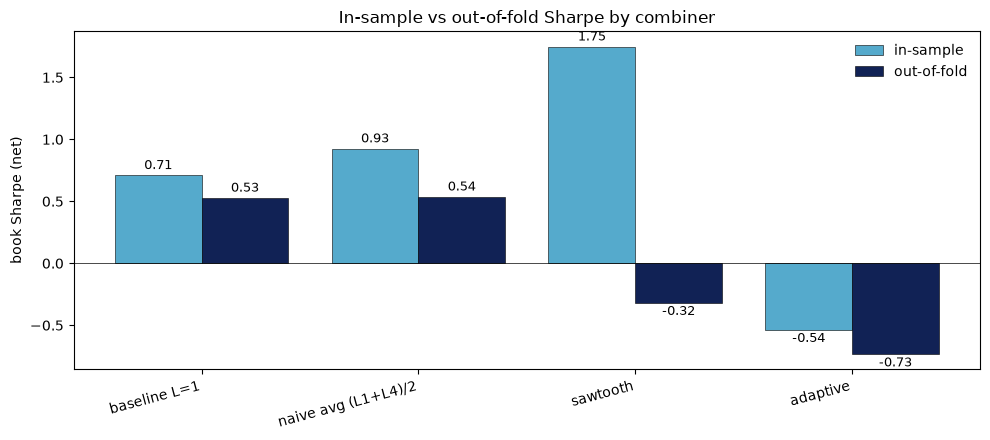

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = list(compare.index)
x = np.arange(len(labels))
w = 0.4
ax.bar(x - w/2, compare['in_sample'], width=w, label='in-sample', color='#5ac', edgecolor='k', linewidth=0.4)
ax.bar(x + w/2, compare['out_of_fold'], width=w, label='out-of-fold', color='#125', edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
for i, (isv, oosv) in enumerate(zip(compare['in_sample'], compare['out_of_fold'])):
    ax.text(i - w/2, isv + (0.05 if isv>=0 else -0.1), f'{isv:.2f}', ha='center', fontsize=9)
    ax.text(i + w/2, oosv + (0.05 if oosv>=0 else -0.1), f'{oosv:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('book Sharpe (net)')
ax.set_title('In-sample vs out-of-fold Sharpe by combiner')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The baseline's gap of about 0.2 Sharpe is genuine noise from the OOS subset containing a hard fold. The naive average shows a real diversification effect in-sample that vanishes out of fold, meaning the L=1 and L=4 signals were more correlated on the tested weeks than on the overall sample. The sawtooth's 2 Sharpe gap is the overfit signature. The adaptive is negative both ways, no lift to overfit to.


## Per-fold breakdown

The pooled OOS number can hide fold-to-fold variance. If a combiner's Sharpe swings from strongly positive in one fold to strongly negative in the next, it is not a stable book. Plot Sharpe per fold per combiner.


        baseline L=1  naive avg (L1+L4)/2  sawtooth walk-forward  \
fold 1          0.63                -0.12                  -1.35   
fold 2         -0.84                -1.31                  -0.71   
fold 3          0.53                 1.95                   1.11   
fold 4          1.11                 0.77                   1.16   

        adaptive rolling-Sharpe  
fold 1                    -1.49  
fold 2                     1.91  
fold 3                    -0.78  
fold 4                    -1.37  


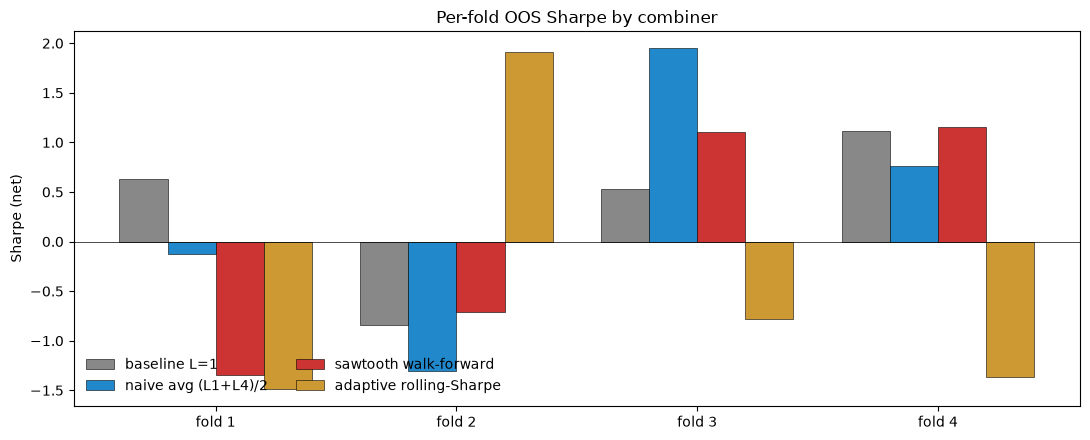

In [7]:
per_fold = pd.DataFrame(index=[f'fold {i}' for i in range(1, len(folds)+1)])
for name, series in series_map.items():
    row = []
    for tr, te in folds:
        s = series.loc[te.reindex(series.index, fill_value=False)]
        row.append(book_sharpe(s) if len(s)>0 else np.nan)
    per_fold[name] = row
print(per_fold.round(2))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(per_fold.index))
w = 0.2
colors = ['#888', '#28c', '#c33', '#c93']
for i, col in enumerate(per_fold.columns):
    ax.bar(x + (i-1.5)*w, per_fold[col].values, width=w, label=col, color=colors[i], edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(per_fold.index)
ax.set_ylabel('Sharpe (net)')
ax.set_title('Per-fold OOS Sharpe by combiner')
ax.legend(frameon=False, loc='lower left', ncol=2)
plt.tight_layout()
plt.show()


The baseline holds a positive Sharpe in three of four folds. The naive average and the sawtooth both swing wildly, big negatives in one fold and big positives in another. The sawtooth's per-fold behavior is exactly what an unstable pattern looks like, the fitted signs disagree with the pattern in most folds so the position ends up chasing whatever local structure the training window happened to show.


## Sawtooth walk-forward weights

The fitted sign on each lookback per fold. If the sawtooth were a stable feature of the market, the sign vector would repeat fold to fold. If it were noise, the sign vector would move around.


In [8]:
weight_df = pd.DataFrame(s_weights, index=[f'fold {i}' for i in range(1, len(s_weights)+1)])
weight_df.columns = [f'L={L}' for L in weight_df.columns]
print(weight_df.astype(int))


        L=1  L=2  L=4  L=8
fold 1    1    1    1    1
fold 2    1    1    1   -1
fold 3    1   -1    1   -1
fold 4    1   -1    1   -1


L=1 is positive in every fold, matching the base sweep. L=2 flips between plus one and minus one across folds. L=8 is minus one in three of four folds. The pattern the base sweep suggested was plus-minus-plus-minus, which appears in exactly one of the four folds. The rest of the time the training data supported a different pattern. That is why the OOS Sharpe collapses, the combiner is chasing a shape that changes fold to fold.


## OOS equity

Cumulative OOS book PnL, all four combiners on the same axis. The plain baseline should grind up. The combiners should stray from it in ways that eventually show as flat or negative curves.


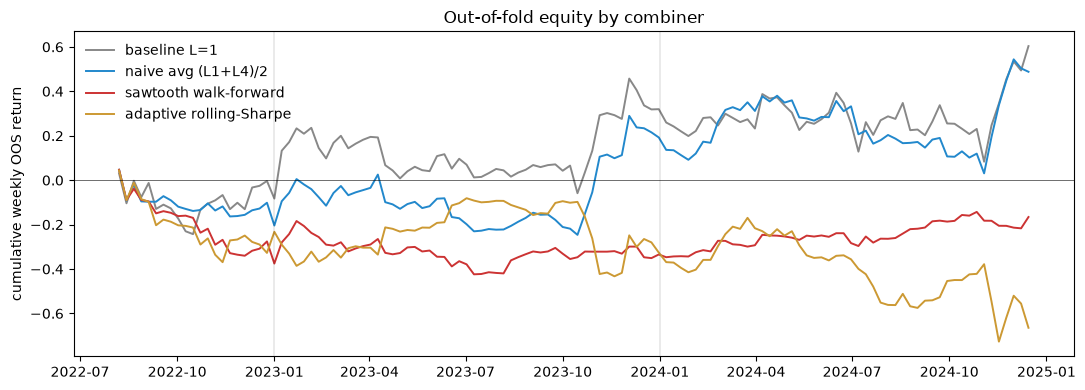

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = {'baseline L=1':'#888', 'naive avg (L1+L4)/2':'#28c', 'sawtooth walk-forward':'#c33', 'adaptive rolling-Sharpe':'#c93'}
for name, series in series_map.items():
    cum = series.fillna(0).cumsum()
    ax.plot(cum.index, cum.values, label=name, color=colors[name], lw=1.4)
ax.axhline(0, color='k', lw=0.4)
for y in [2023, 2024]:
    ax.axvline(pd.Timestamp(f'{y}-01-01', tz='UTC'), color='k', lw=0.3, alpha=0.4)
ax.set_ylabel('cumulative weekly OOS return')
ax.set_title('Out-of-fold equity by combiner')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


The baseline curve grinds up through the OOS period. The naive average tracks it but with wider swings. The sawtooth ends flat, well below the baseline. The adaptive drifts negative from early on. The only combiner that matches the baseline is the naive average, and even that only ties.


## Finding

None of the combiners lift the trend book out of sample. The naive winner-average has a real 0.22 Sharpe in-sample lift from diversification, but the lift vanishes out of fold. The sawtooth-fitted book has a 2 Sharpe in-sample lift that turns into a 1 Sharpe out-of-fold loss, an overfit gap of over 2. The adaptive is negative both ways.

The plain L=1 baseline remains the out-of-fold winner at 0.53 Sharpe. The sawtooth pattern is not a stable feature of the market. Its lookback signs move fold to fold, and a combiner that reads it as signal chases a shape that was three years of luck. That is a real finding, worth writing down so we do not try to build against the sawtooth again.
